# NPS 기반 추천 의향 세그먼트 분석

---

## 분석 개요

`03_nps`를 **SQL 중심 워크플로**로 구성한 분석이다. 세그먼트 분류·분포·교차집계·인구통계는 한 개의 SQL 파일 `../sql/03_nps.sql`에 모으고(쿼리별 `-- name:` 마커), 노트북은 이름으로 호출해 **시각화·해석**을 담당한다.

| 분석 단계 | 처리 위치 | 이유 |
|-----------|-----------|------|
| NPS 세그먼트 분류, 분포, 세그먼트×의향/성별/연령 교차집계 | **SQL** (`-- name:` 쿼리) | 분류·집계는 SQL의 본령 |
| Q4 플랫폼 · Q12 재구매 이유 · Q13 불만족 (다중응답) | **pandas** | explode·응답자 비율은 SQL 부적합 |
| 카이제곱 + 조정 표준화잔차 (가설 2) | **분할표는 SQL, 검정은 scipy** | 집계는 SQL, 검정은 Python |
| NPS × 콘텐츠 탐색/월 지출 스피어만 (4-2) | **점수는 SQL 뷰, 검정은 scipy** | 매핑은 SQL, 상관은 Python |

- 분석 대상: 플랫폼 사용자 200명 (NPS base) / 구매자 191명 (Q12 등)
- ⚠️ **데이터 한계**: 횡단면 자기보고 설문이며 단일 NPS 측정이라 표본오차가 크다. 다중응답 문항은 통계 검정 부적합이라 비율 비교만 한다.


In [1]:
import os
from pathlib import Path
import re

import pandas as pd
import numpy as np
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
load_dotenv()

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

SQL_FILE = Path('../sql/03_nps.sql')

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)
print('로드된 쿼리:', list(Q))

def run(name):
    return pd.read_sql(Q[name], engine)

def execute(name):
    with engine.begin() as conn:
        for stmt in [s for s in Q[name].split(';') if s.strip()]:
            conn.execute(text(stmt))

로드된 쿼리: ['nps_scored_view', 'base_scored', 'nps_distribution', 'continue_counts', 'segment_continue_cross', 'gender_by_segment', 'age_by_segment']


---

## 0. SQL 세그먼트·점수 뷰 구축

- `Q["nps_scored_view"]` — NPS 세그먼트(Promoter/Passive/Detractor)와 콘텐츠·지출 점수를 만드는 뷰(`nps_scored`).
- `Q["base_scored"]` — 행 단위 데이터(`df`). 다중응답·카이제곱·스피어만 등 pandas 처리의 입력.


In [3]:
execute('nps_scored_view')
df = run('base_scored')

n_users = len(df)
print(f'플랫폼 사용자(NPS base): {n_users}명')
assert n_users == 200, f'모수 불일치: {n_users} (기대 200)'

플랫폼 사용자(NPS base): 200명


---

## NPS 분류
- Q15. 현재 사용하는 패션 플랫폼을 지인에게 추천할 의향이 얼마나 있나요?
---
NPS 점수(0-10) 분포를 확인하고, 표준 기준에 따라 세 그룹으로 분류한다.

| 세그먼트 | 점수 | 의미 |
|---------|------|------|
| Promoter 🟢 | 9-10 | 적극적 추천 의향 |
| Passive 🟡 | 7-8 | 중립 |
| Detractor 🔴 | 0-6 | 낮은 추천 의향 / 비추천층 |


In [4]:
# NPS 원점수(0-10) 분포는 SQL에서 (nps_distribution — GROUP BY)
nps_dist = run('nps_distribution')
nps_dist

,nps,n
0,0,2
1,1,5
2,2,4
3,3,6
4,4,11
5,5,23
6,6,37
7,7,51
8,8,37
9,9,13


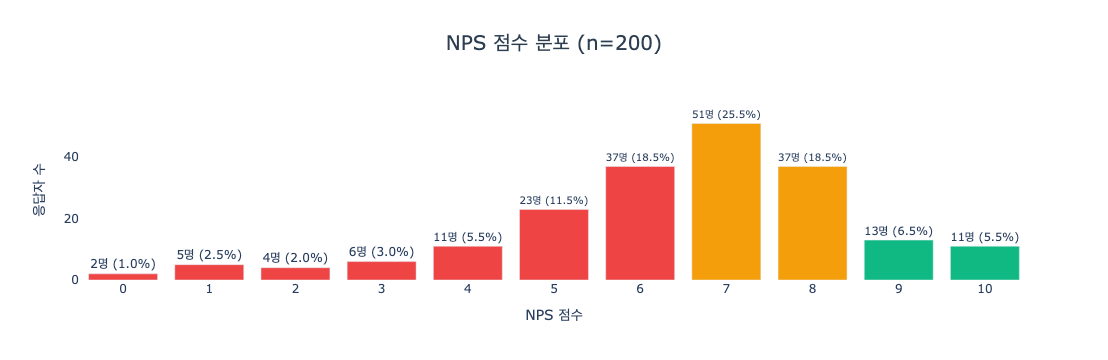

In [5]:
nps_plot_text = [
    f"{int(n)}명 ({n / nps_dist['n'].sum() * 100:.1f}%)"
    for n in nps_dist['n']
]

fig = go.Figure(go.Bar(
    x=nps_dist['nps'].astype(str),
    y=nps_dist['n'],
    marker_color=['#EF4444' if x <= 6 else '#F59E0B' if x <= 8 else '#10B981' for x in nps_dist['nps']],
    text=nps_plot_text,
    textposition='outside'
))

fig.update_layout(
    title=dict(text=f'NPS 점수 분포 (n={len(df)})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='NPS 점수',
    yaxis_title='응답자 수',
    yaxis=dict(range=[0, nps_dist['n'].max() * 1.15]),
    plot_bgcolor='white',
    showlegend=False
)

fig.show()

In [6]:
SEGMENT_ORDER = ['Promoter', 'Passive', 'Detractor']
SEGMENT_COLORS = {'Promoter': '#10B981', 'Passive': '#F59E0B', 'Detractor': '#EF4444'}

segment_counts = (
    df['nps_segment']
    .value_counts()
    .reindex(SEGMENT_ORDER)
    .reset_index()
    .rename(columns={'nps_segment': '세그먼트', 'count': '응답자 수'})
)
segment_counts

,세그먼트,응답자 수
0,Promoter,24
1,Passive,88
2,Detractor,88


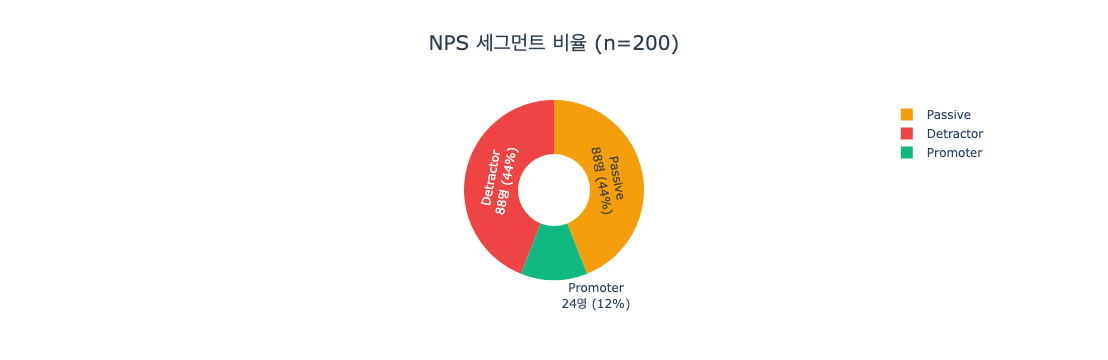

In [7]:
fig = go.Figure(go.Pie(
    labels=segment_counts['세그먼트'],
    values=segment_counts['응답자 수'],
    marker_colors=[SEGMENT_COLORS[s] for s in segment_counts['세그먼트']],
    texttemplate='%{label}<br>%{value}명 (%{percent})',
    textinfo='text',
    hole=0.4
))
fig.update_layout(
    title=dict(text=f'NPS 세그먼트 비율 (n={len(df)})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white'
)
fig.show()

In [8]:
n = len(df)
pct_promoter = (df['nps_segment'] == 'Promoter').sum() / n * 100
pct_passive = (df['nps_segment'] == 'Passive').sum() / n * 100
pct_detractor = (df['nps_segment'] == 'Detractor').sum() / n * 100
nps_score = round(pct_promoter - pct_detractor, 1)

print(f'Promoter {pct_promoter:.1f}% / Passive {pct_passive:.1f}% / Detractor {pct_detractor:.1f}%')
print(f'NPS Score: {nps_score}')

Promoter 12.0% / Passive 44.0% / Detractor 44.0%
NPS Score: -32.0


---

## NPS(Net Promoter Score) 최종 산출 및 요약
시각화된 응답 분포를 바탕으로 산출한 최종 NPS 지표와 세그먼트별 요약은 아래와 같다.

### 주요 지표 요약

| 지표 분석 항목 | 결과 값 | 비고 |
| :--- | :---: | :--- |
| **전체 응답자 수 (N)** | **200명** | NPS 유효 응답 기준 |
| **추천 고객 (Promoter 🟢)** | **24명 (12.0%)** | 9-10점 응답자 |
| **중립 고객 (Passive 🟡)** | **88명 (44.0%)** | 7-8점 응답자 |
| **비추천 고객 (Detractor 🔴)** | **88명 (44.0%)** | 0-6점 응답자 |
| **최종 NPS 스코어** | **-32.0** | 지수 범위: -100 ~ +100 |

**NPS 계산 공식**
$$\text{NPS} = \text{Promoter \%} - \text{Detractor \%} = 12.0\% - 44.0\% = -32.0$$

> ### 섹션 결론
> - NPS Score는 **-32.0** 으로, 추천 고객보다 비추천 고객이 더 두터운 구조다.
> - Promoter 🟢는 **24명(12.0%)** 으로 작아 자발적 추천 확산 기반은 제한적이다.
> - 다만 이 단계에서는 이탈 위험으로 단정하지 않고, 이후 계속 사용 의향과 함께 해석한다.


---

## 보조 관찰 — 플랫폼 선택자별 NPS (참고)
Q6에서 선택한 플랫폼별로 NPS 분포를 참고용으로 살펴본다. 다만 Q6는 다중응답 문항이고, Q15의 NPS는 개별 플랫폼별 점수가 아니라 현재 사용하는 플랫폼에 대한 전반적 추천 의향에 가깝다.

따라서 아래 결과는 **공식적인 플랫폼별 NPS** 가 아니라, 특정 플랫폼을 선택한 사용자들의 추천 의향 분포를 보는 **참고 지표** 로만 해석한다. 점수 막대와 함께 Promoter·Passive·Detractor 구성 비율도 같이 확인한다.

**해석 한계**
- 한 사용자가 여러 플랫폼을 선택하면 동일한 NPS가 여러 플랫폼에 중복 반영된다.
- NPS 문항이 특정 플랫폼 하나를 지정해 묻지 않았기 때문에, 점수를 특정 브랜드/앱의 성과로 귀속할 수 없다.
- 선택자 수가 작은 플랫폼은 NPS Score 변동성이 매우 크므로, 시각화는 선택자 수 10명 이상 플랫폼만 참고한다.
- 점수 막대의 `명(%)` 라벨은 각 플랫폼 선택자 수와 전체 NPS 유효 응답자(n=200) 대비 선택 비율을 함께 표시한 것이다.


In [9]:
platform_nps = (
    df[['user_id', 'platforms', 'nps', 'nps_segment']]
    .dropna(subset=['platforms'])
    .assign(platform=lambda x: x['platforms'].str.split(', '))
    .explode('platform')
    .assign(platform=lambda x: x['platform'].str.strip())
)

platform_summary = (
    platform_nps
    .groupby('platform')
    .agg(
        선택자수=('user_id', 'nunique'),
        평균_NPS=('nps', 'mean'),
        Promoter=('nps_segment', lambda s: (s == 'Promoter').sum()),
        Passive=('nps_segment', lambda s: (s == 'Passive').sum()),
        Detractor=('nps_segment', lambda s: (s == 'Detractor').sum()),
    )
    .reset_index()
    .assign(
        Promoter_pct=lambda x: (x['Promoter'] / x['선택자수'] * 100).round(1),
        Detractor_pct=lambda x: (x['Detractor'] / x['선택자수'] * 100).round(1),
        선택자_NPS=lambda x: (x['Promoter_pct'] - x['Detractor_pct']).round(1),
        평균_NPS=lambda x: x['평균_NPS'].round(2),
    )
    .sort_values('선택자수', ascending=False)
)
platform_summary

,platform,선택자수,평균_NPS,Promoter,Passive,Detractor,Promoter_pct,Detractor_pct,선택자_NPS
6,무신사,125,6.54,16,59,50,12.8,40.0,-27.2
8,에이블리,63,7.02,12,31,20,19.0,31.7,-12.7
11,지그재그,50,6.32,4,21,25,8.0,50.0,-42.0
10,종합 쇼핑몰,47,6.43,2,23,22,4.3,46.8,-42.5
2,KREAM,35,6.17,4,12,19,11.4,54.3,-42.9
0,29CM,21,6.19,4,6,11,19.0,52.4,-33.4
4,기타,10,6.60,1,4,5,10.0,50.0,-40.0
1,4910,7,6.43,2,3,2,28.6,28.6,0.0
3,W컨셉,2,7.50,0,2,0,0.0,0.0,0.0
5,룩핀,2,7.00,0,2,0,0.0,0.0,0.0


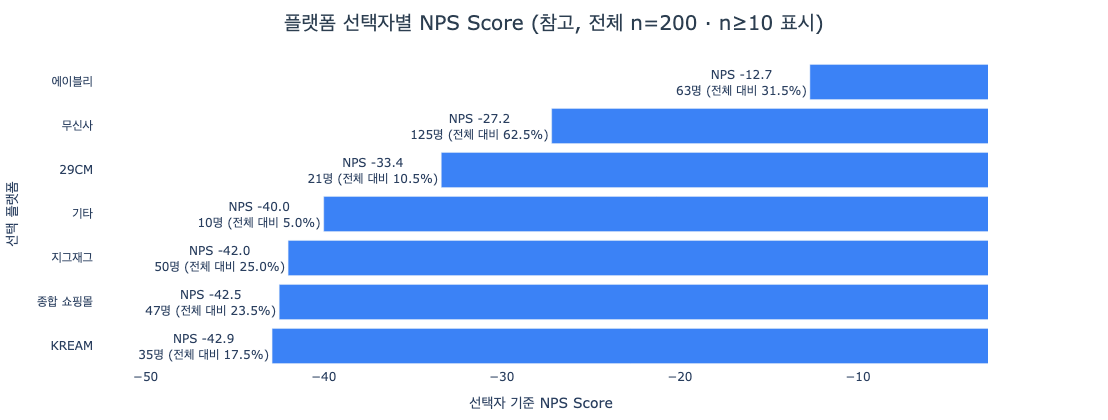

In [10]:
plot_platform = platform_summary[platform_summary['선택자수'] >= 10].sort_values('선택자_NPS')
platform_plot_text = [
    f"NPS {score:.1f}<br>{int(n)}명 (전체 대비 {n / len(df) * 100:.1f}%)"
    for score, n in zip(plot_platform['선택자_NPS'], plot_platform['선택자수'])
]

fig = go.Figure(go.Bar(
    x=plot_platform['선택자_NPS'],
    y=plot_platform['platform'],
    orientation='h',
    marker_color='#3B82F6',
    text=platform_plot_text,
    textposition='outside'
))

fig.update_layout(
    title=dict(text=f'플랫폼 선택자별 NPS Score (참고, 전체 n={len(df)} · n≥10 표시)', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='선택자 기준 NPS Score',
    yaxis_title='선택 플랫폼',
    plot_bgcolor='white',
    height=420,
    margin=dict(l=20, r=120, t=60, b=40),
    xaxis=dict(
        range=[plot_platform['선택자_NPS'].min() - 10,
               plot_platform['선택자_NPS'].max() + 10]
    )
)

fig.show()

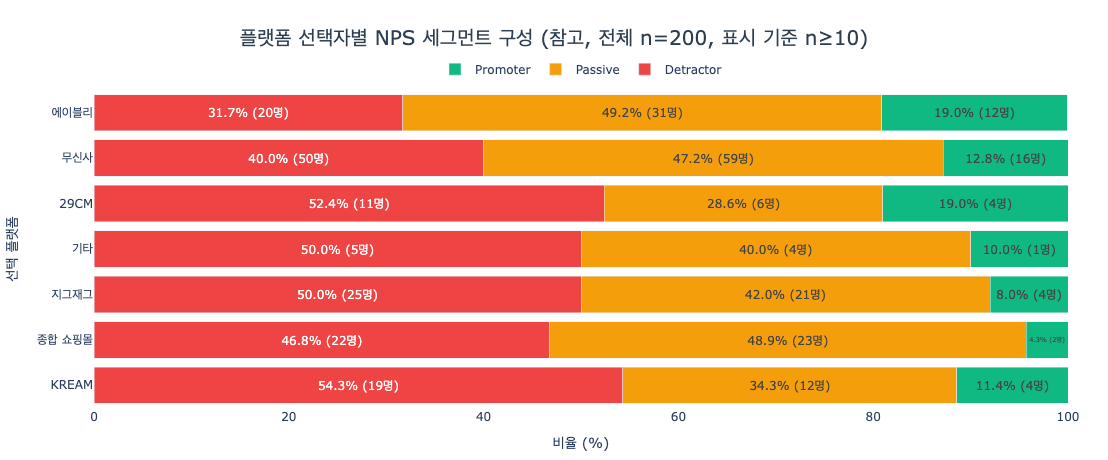

In [11]:
platform_seg = (
    platform_summary[platform_summary['선택자수'] >= 10]
    .set_index('platform')
    .loc[plot_platform['platform'], ['Detractor', 'Passive', 'Promoter', '선택자수']]
)
platform_seg_pct = (
    platform_seg[['Detractor', 'Passive', 'Promoter']]
    .div(platform_seg['선택자수'], axis=0)
    .mul(100)
    .round(1)
)

fig = go.Figure()
for seg in ['Detractor', 'Passive', 'Promoter']:
    fig.add_trace(go.Bar(
        name=seg,
        x=platform_seg_pct[seg],
        y=platform_seg_pct.index,
        orientation='h',
        marker_color=SEGMENT_COLORS[seg],
        text=[f"{pct:.1f}% ({int(n)}명)" for pct, n in zip(platform_seg_pct[seg], platform_seg[seg])],
        textposition='inside',
        insidetextanchor='middle'
    ))

fig.update_layout(
    barmode='stack',
    title=dict(text=f'플랫폼 선택자별 NPS 세그먼트 구성 (참고, 전체 n={len(df)}, 표시 기준 n≥10)', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='비율 (%)',
    yaxis_title='선택 플랫폼',
    xaxis=dict(range=[0, 100]),
    plot_bgcolor='white',
    height=460,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
    margin=dict(l=20, r=40, t=90, b=40)
)
fig.show()

### 보조 관찰 결과 — 플랫폼별 성과가 아니라 선택자 특성으로 해석
_집계: pandas (Q4 플랫폼 다중응답) · SQL 부적합_


선택자 수 10명 이상 플랫폼 기준으로는 에이블리 선택자의 NPS가 상대적으로 덜 낮고, KREAM·종합 쇼핑몰·지그재그 선택자의 NPS가 더 낮게 나타난다.

| 플랫폼 | 선택자 수 | 평균 추천점수(0-10) | 선택자 기준 NPS Score | Detractor 🔴 | Passive 🟡 | Promoter 🟢 |
|--------|----------|----------|------------------------|--------------|------------|-------------|
| 에이블리 | 63 | 7.02 | -12.7 | 20명 (31.7%) | 31명 (49.2%) | 12명 (19.0%) |
| 무신사 | 125 | 6.54 | -27.2 | 50명 (40.0%) | 59명 (47.2%) | 16명 (12.8%) |
| 29CM | 21 | 6.19 | -33.4 | 11명 (52.4%) | 6명 (28.6%) | 4명 (19.0%) |
| 기타 | 10 | 6.60 | -40.0 | 5명 (50.0%) | 4명 (40.0%) | 1명 (10.0%) |
| 지그재그 | 50 | 6.32 | -42.0 | 25명 (50.0%) | 21명 (42.0%) | 4명 (8.0%) |
| 종합 쇼핑몰 | 47 | 6.43 | -42.5 | 22명 (46.8%) | 23명 (48.9%) | 2명 (4.3%) |
| KREAM | 35 | 6.17 | -42.9 | 19명 (54.3%) | 12명 (34.3%) | 4명 (11.4%) |

> ### 섹션 결론
> - 에이블리는 Promoter 🟢 비율이 **19.0%** 로 상대적으로 높고, KREAM은 Detractor 🔴 비율이 **54.3%** 로 높다.
> - 다만 Q6는 다중응답 문항이므로, 이 결과는 플랫폼별 만족도 순위가 아니라 **선택자군의 추천 의향 분포** 로 해석한다.
> - 후속 해석에서는 `06_channel.ipynb`의 멀티호밍 분석과 함께 읽는 것이 안전하다.

---

## 1. 재구매 이유
- Q12. 같은 플랫폼에서 다시 구매하게 된 가장 큰 이유는 무엇인가요? (최대 2개 선택)

---

**분석 질문 1** — Promoter 🟢 는 브랜드·제품 같은 능동적 선택 이유가 더 크게 나타나고, Detractor 🔴 는 관성적 재구매 이유가 더 크게 나타나는가?

- 근거: 전체 재구매 1위는 쿠폰/혜택(83건)이지만, 세그먼트별로 재구매 동인이 다를 가능성이 있다.
- **분석 대상**: 최근 6개월 내 구매 경험자(Q9 ≠ '구매하지 않음') — Google Forms 분기상 Q12는 구매자에게만 노출됨
- 검증: NPS 세그먼트별 재구매 이유 비율 비교(기술통계)

구매 경험자의 재구매 이유 전체 빈도를 확인하고, NPS 세그먼트별 패턴을 비교한다.

In [12]:
repurchase_all = (
    df['repurchase_reason'].dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
    .rename(columns={'repurchase_reason': '재구매 이유', 'count': '언급 수'})
)
repurchase_all

,재구매 이유,언급 수
0,쿠폰 / 적립금 등 혜택이 좋아서,83
1,배송 또는 상품 품질이 만족스러워서,67
2,원하는 브랜드나 상품이 있어서,67
3,특별한 이유 없이 익숙해서,59
4,앱 UI/UX가 편리하고 사용하기 좋아서,38


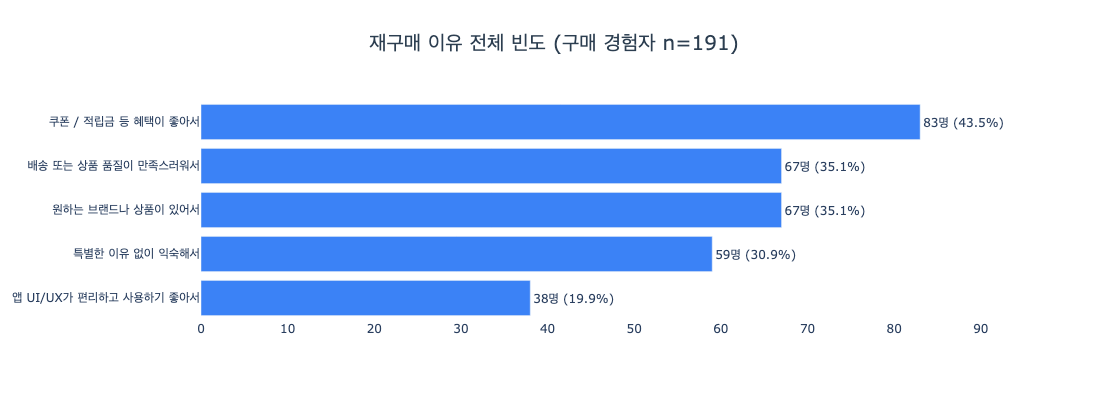

In [13]:
repurchase_base_n = df['repurchase_reason'].notna().sum()
repurchase_text = [
    f"{int(n)}명 ({n / repurchase_base_n * 100:.1f}%)"
    for n in repurchase_all['언급 수']
]

fig = go.Figure(go.Bar(
    x=repurchase_all['언급 수'],
    y=repurchase_all['재구매 이유'],
    orientation='h',
    marker_color='#3B82F6',
    text=repurchase_text,
    textposition='outside'
))
fig.update_layout(
    title=dict(text=f'재구매 이유 전체 빈도 (구매 경험자 n={repurchase_base_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis=dict(range=[0, repurchase_all['언급 수'].max() * 1.15]),
    plot_bgcolor='white',
    height=400,
    yaxis=dict(autorange='reversed')
)
fig.show()

In [14]:
# 분모: 세그먼트별 Q12 응답자 수 (구매자 — repurchase_reason notna)
seg_resp_n = (
    df[df['repurchase_reason'].notna()]
    .groupby('nps_segment')
    .size()
    .reset_index(name='응답자수')
)

# 항목별 언급 수
seg_repurchase = (
    df[['nps_segment', 'repurchase_reason']].dropna()
    .assign(reason=lambda x: x['repurchase_reason'].str.split(', '))
    .explode('reason')
    .assign(reason=lambda x: x['reason'].str.strip())
    .groupby(['nps_segment', 'reason'])
    .size()
    .reset_index(name='언급 수')
)

# 응답자 비율 = 항목 선택자 수 / 세그먼트 응답자 수 (다중응답 표준)
seg_repurchase_pct = (
    seg_repurchase
    .merge(seg_resp_n, on='nps_segment')
    .assign(비율=lambda x: (x['언급 수'] / x['응답자수'] * 100).round(1))
)
seg_repurchase_pct

,nps_segment,reason,언급 수,응답자수,비율
0,Detractor,배송 또는 상품 품질이 만족스러워서,29,82,35.4
1,Detractor,앱 UI/UX가 편리하고 사용하기 좋아서,15,82,18.3
2,Detractor,원하는 브랜드나 상품이 있어서,25,82,30.5
3,Detractor,쿠폰 / 적립금 등 혜택이 좋아서,29,82,35.4
4,Detractor,특별한 이유 없이 익숙해서,27,82,32.9
5,Passive,배송 또는 상품 품질이 만족스러워서,29,85,34.1
6,Passive,앱 UI/UX가 편리하고 사용하기 좋아서,17,85,20.0
7,Passive,원하는 브랜드나 상품이 있어서,31,85,36.5
8,Passive,쿠폰 / 적립금 등 혜택이 좋아서,43,85,50.6
9,Passive,특별한 이유 없이 익숙해서,28,85,32.9


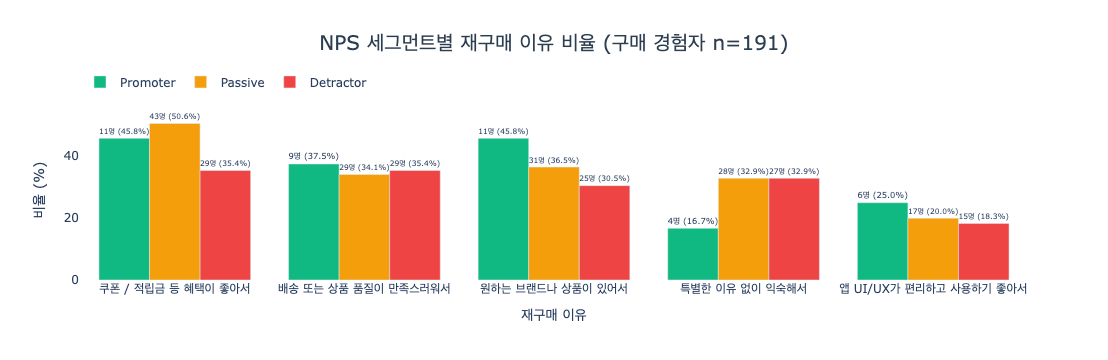

In [15]:
top_reasons = repurchase_all['재구매 이유'].tolist()

fig = go.Figure()
for seg, color in zip(SEGMENT_ORDER, [SEGMENT_COLORS[s] for s in SEGMENT_ORDER]):
    data_pct = (
        seg_repurchase_pct[seg_repurchase_pct['nps_segment'] == seg]
        .set_index('reason')['비율']
        .reindex(top_reasons, fill_value=0)
    )
    data_n = (
        seg_repurchase_pct[seg_repurchase_pct['nps_segment'] == seg]
        .set_index('reason')['언급 수']
        .reindex(top_reasons, fill_value=0)
    )
    label_text = [
        f'{int(n)}명 ({pct:.1f}%)' if pct > 0 else ''
        for n, pct in zip(data_n, data_pct)
    ]
    fig.add_trace(go.Bar(
        name=seg,
        x=top_reasons,
        y=data_pct.values,
        marker_color=color,
        text=label_text,
        textposition='outside'
    ))

fig.update_layout(
    barmode='group',
    title=dict(text=f'NPS 세그먼트별 재구매 이유 비율 (구매 경험자 n={repurchase_base_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='재구매 이유',
    yaxis_title='비율 (%)',
    yaxis=dict(range=[0, seg_repurchase_pct['비율'].max() * 1.15]),
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

### 분석 질문 1 결과: Promoter는 능동 선택, Passive·Detractor는 관성 경향
_집계: pandas (Q12 재구매 이유 다중응답)_


**세그먼트별 재구매 이유 응답자 비율** _(분모: 세그먼트별 최근 6개월 내 구매 경험자 수, 다중응답이라 합은 100% 초과)_

| 재구매 이유 | Promoter 🟢 (n=24) | Passive 🟡 (n=85) | Detractor 🔴 (n=82) | 차이 (P-D) |
|-----------|--------------------|-------------------|----------------------|-----------|
| 브랜드/상품이 있어서 | **11명 (45.8%)** | 31명 (36.5%) | 25명 (30.5%) | **+15.3%p** |
| 쿠폰/적립금 등 혜택 | 11명 (45.8%) | **43명 (50.6%)** | 29명 (35.4%) | +10.4%p |
| 배송·상품 품질 만족 | 9명 (37.5%) | 29명 (34.1%) | 29명 (35.4%) | +2.1%p |
| UI/UX가 편리해서 | 6명 (25.0%) | 17명 (20.0%) | 15명 (18.3%) | +6.7%p |
| 익숙해서(관성) | 4명 (16.7%) | 28명 (32.9%) | 27명 (32.9%) | **-16.2%p** |

> ### 섹션 결론
> - Promoter 🟢는 브랜드/상품 응답이 **45.8%** 로 Detractor 🔴 **30.5%** 보다 높다.
> - Passive 🟡는 쿠폰/혜택 응답이 **50.6%** 로 가장 높고, Passive 🟡·Detractor 🔴 모두 `익숙해서` 응답이 **32.9%** 다.
> - 따라서 핵심 차이는 단순한 `혜택 vs 가치`보다 **능동적 선택(Promoter 🟢) vs 관성적 잔류(Passive 🟡/Detractor 🔴)** 축에서 더 잘 드러난다.


---

## 2. 계속 사용 의향
- Q14. 지금 가장 자주 사용하는 플랫폼을 앞으로도 계속 사용할 것 같나요?

플랫폼 사용자의 계속 사용 의향 전체 분포를 살펴보고, NPS 세그먼트별 차이는 히트맵으로 점검한다.

---

**가설 2** — NPS 세그먼트에 따라 앞으로의 계속 사용 의향 분포가 다를 수 있다.

- 근거: EDA에서 NPS ↔ continue_use 스피어만 ρ=0.400으로 양의 관계가 관찰됨
- 분석 방법: NPS 세그먼트 × 계속 사용 의향 교차표와 카이제곱 독립성 검정
- 해석 기준: 검정 결과만으로 결론을 확정하지 않고, 실제 비율 차이와 효과 크기(Cramér's V)를 함께 본다.

카이제곱 검정은 결론을 확정하기 위한 목적보다는,
NPS 세그먼트별 계속 사용 의향 분포가 독립적으로 보기 어려운지 확인하는 **보조 절차** 로 사용한다.


In [16]:
CONTINUE_ORDER = ['계속 사용할 것 같다', '아마 사용할 것 같다', '잘 모르겠다', '아마 사용하지 않을 것 같다', '다른 앱으로 바꿀 것 같다']

In [17]:
# 계속 사용 의향 분포는 SQL에서 (continue_counts — GROUP BY)
continue_counts = (
    run('continue_counts')
    .set_index('continue_use')['n']
    .reindex(CONTINUE_ORDER)
    .reset_index(name='응답자 수')
    .rename(columns={'continue_use': '계속 사용 의향'})
)
continue_counts

,계속 사용 의향,응답자 수
0,계속 사용할 것 같다,110
1,아마 사용할 것 같다,77
2,잘 모르겠다,9
3,아마 사용하지 않을 것 같다,3
4,다른 앱으로 바꿀 것 같다,1


In [18]:
positive_intent = continue_counts[
    continue_counts['계속 사용 의향'].isin(['계속 사용할 것 같다', '아마 사용할 것 같다'])
]['응답자 수'].sum()
total_continue = continue_counts['응답자 수'].sum()

print(f'계속 사용 긍정권: {positive_intent}명 / 전체 {total_continue}명 ({positive_intent/total_continue*100:.1f}%)')

계속 사용 긍정권: 187명 / 전체 200명 (93.5%)


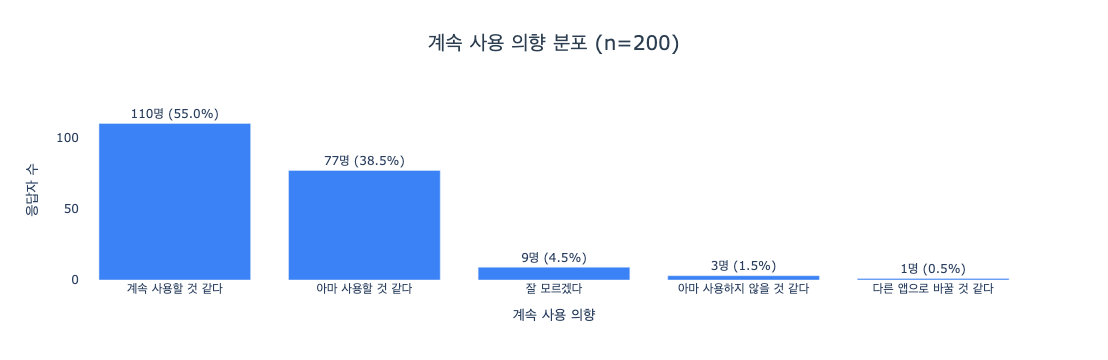

In [19]:
continue_total_n = continue_counts['응답자 수'].sum()
continue_text = [
    f"{int(n)}명 ({n / continue_total_n * 100:.1f}%)"
    for n in continue_counts['응답자 수']
]

fig = go.Figure(go.Bar(
    x=continue_counts['계속 사용 의향'],
    y=continue_counts['응답자 수'],
    marker_color='#3B82F6',
    text=continue_text,
    textposition='outside'
))
fig.update_layout(
    title=dict(text=f'계속 사용 의향 분포 (n={continue_total_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='계속 사용 의향',
    yaxis_title='응답자 수',
    yaxis=dict(range=[0, continue_counts['응답자 수'].max() * 1.15]),
    plot_bgcolor='white'
)
fig.show()

In [20]:
# 세그먼트 × 계속 사용 의향 교차 카운트는 SQL에서 (segment_continue_cross)
# (카이제곱·조정 표준화잔차는 이 분할표를 받아 pandas/scipy에서 계산)
cross_raw = run('segment_continue_cross')
cross_raw

,nps_segment,continue_use,n
0,Passive,계속 사용할 것 같다,56
1,Passive,아마 사용할 것 같다,31
2,Promoter,계속 사용할 것 같다,22
3,Detractor,아마 사용할 것 같다,45
4,Detractor,계속 사용할 것 같다,32
5,Detractor,잘 모르겠다,8
6,Promoter,아마 사용할 것 같다,1
7,Promoter,잘 모르겠다,1
8,Passive,아마 사용하지 않을 것 같다,1
9,Detractor,아마 사용하지 않을 것 같다,2


In [21]:
cross_pivot = (
    cross_raw
    .pivot(index='nps_segment', columns='continue_use', values='n')
    .reindex(index=SEGMENT_ORDER, columns=CONTINUE_ORDER)
    .fillna(0)
)

cross_pct = (
    cross_pivot
    .div(cross_pivot.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)
cross_pct

continue_use,계속 사용할 것 같다,아마 사용할 것 같다,잘 모르겠다,아마 사용하지 않을 것 같다,다른 앱으로 바꿀 것 같다
nps_segment,,,,,
Promoter,91.7,4.2,4.2,0.0,0.0
Passive,63.6,35.2,0.0,1.1,0.0
Detractor,36.4,51.1,9.1,2.3,1.1


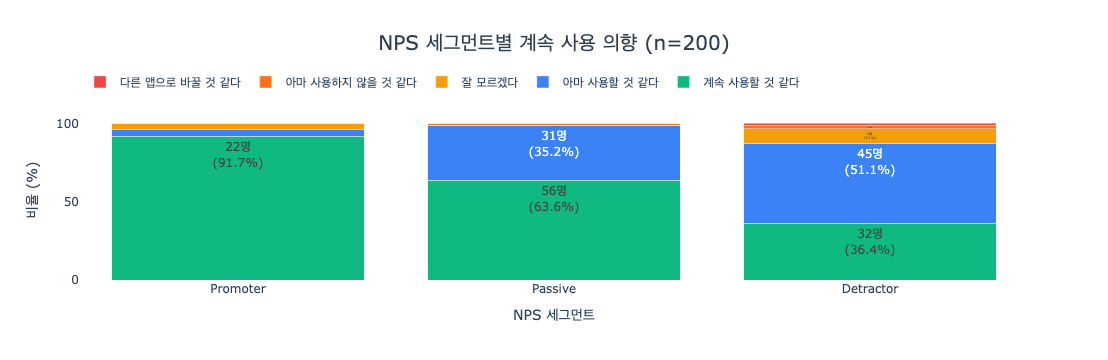

In [22]:
CONTINUE_COLORS = ['#10B981', '#3B82F6', '#F59E0B', '#F97316', '#EF4444']

fig = go.Figure()
for col, color in zip(CONTINUE_ORDER, CONTINUE_COLORS):
    label_text = [
        f"{int(cross_pivot.loc[seg, col])}명<br>({cross_pct.loc[seg, col]:.1f}%)"
        if cross_pivot.loc[seg, col] > 0 else ''
        for seg in SEGMENT_ORDER
    ]
    fig.add_trace(go.Bar(
        name=col,
        x=SEGMENT_ORDER,
        y=cross_pct[col],
        marker_color=color,
        text=label_text,
        textposition='inside'
    ))

fig.update_layout(
    barmode='stack',
    title=dict(text=f'NPS 세그먼트별 계속 사용 의향 (n={int(cross_pivot.values.sum())})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='NPS 세그먼트',
    yaxis_title='비율 (%)',
    yaxis=dict(range=[0, 115]),
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)

fig.show()

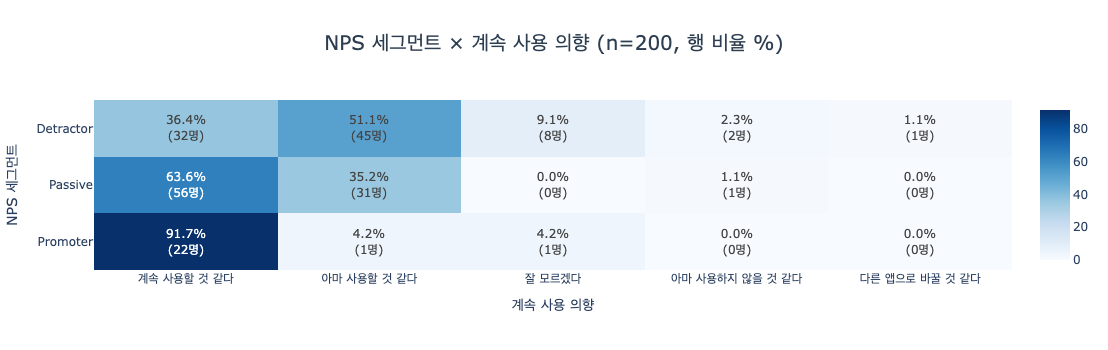

In [23]:
cross_text = [
    [f"{cross_pct.iloc[i, j]:.1f}%<br>({int(cross_pivot.iloc[i, j])}명)" for j in range(cross_pct.shape[1])]
    for i in range(cross_pct.shape[0])
]

fig = go.Figure(go.Heatmap(
    z=cross_pct.values,
    x=CONTINUE_ORDER,
    y=SEGMENT_ORDER,
    colorscale='Blues',
    text=cross_text,
    texttemplate='%{text}',
    showscale=True
))
fig.update_layout(
    title=dict(text=f'NPS 세그먼트 × 계속 사용 의향 (n={int(cross_pivot.values.sum())}, 행 비율 %)', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='계속 사용 의향',
    yaxis_title='NPS 세그먼트',
    plot_bgcolor='white',
    height=350
)
fig.show()

In [24]:
chi2, p, dof, expected = stats.chi2_contingency(cross_pivot)
n_total = cross_pivot.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * min(cross_pivot.shape[0] - 1, cross_pivot.shape[1] - 1)))
expected_df = pd.DataFrame(expected, index=SEGMENT_ORDER, columns=CONTINUE_ORDER).round(2)
below5 = (expected_df < 5).values.sum()

print(f'Chi2={chi2:.3f}, p={p:.4f}, df={dof}')
print(f"Cramér's V = {cramers_v:.3f} (df*=2 기준 small=0.07/medium=0.21)")
print(f'기대빈도 5 미만 셀: {below5}개 / 전체 {expected_df.size}개 ({below5/expected_df.size*100:.1f}%)')
print('전체 기대빈도 (5 미만은 카이제곱 가정 위반):')
expected_df

Chi2=34.008, p=0.0000, df=8
Cramér's V = 0.292 (df*=2 기준 small=0.07/medium=0.21)
기대빈도 5 미만 셀: 9개 / 전체 15개 (60.0%)
전체 기대빈도 (5 미만은 카이제곱 가정 위반):


,계속 사용할 것 같다,아마 사용할 것 같다,잘 모르겠다,아마 사용하지 않을 것 같다,다른 앱으로 바꿀 것 같다
Promoter,13.2,9.24,1.08,0.36,0.12
Passive,48.4,33.88,3.96,1.32,0.44
Detractor,48.4,33.88,3.96,1.32,0.44


In [25]:
# Adjusted standardized residual (Haberman, 1973)
# 정규근사가 더 정확해 셀별 유의성 판단의 표준
row_prop = cross_pivot.sum(axis=1).values / n_total
col_prop = cross_pivot.sum(axis=0).values / n_total

adj_residuals = (cross_pivot.values - expected) / np.sqrt(
    expected * np.outer(1 - row_prop, 1 - col_prop)
)
adj_residuals_df = pd.DataFrame(adj_residuals, index=SEGMENT_ORDER, columns=CONTINUE_ORDER).round(2)
adj_residuals_df

,계속 사용할 것 같다,아마 사용할 것 같다,잘 모르겠다,아마 사용하지 않을 것 같다,다른 앱으로 바꿀 것 같다
Promoter,3.85,-3.68,-0.08,-0.64,-0.37
Passive,2.18,-0.84,-2.72,-0.38,-0.89
Detractor,-4.70,3.26,2.78,0.80,1.13


> 조정 표준화잔차(z) 읽는 법·`|z| > 1.96` 기준 → [docs/METHODS.md](../docs/METHODS.md#조정-표준화잔차-haberman-1973)


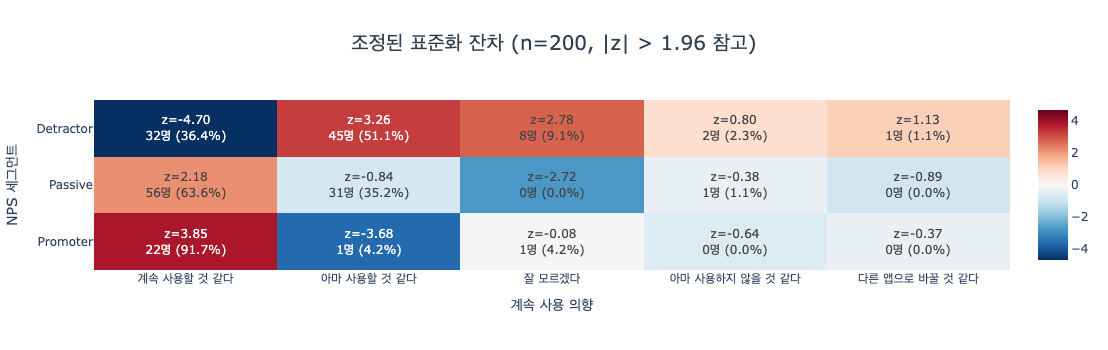

In [26]:
residual_text = [
    [
        f"z={adj_residuals_df.iloc[i, j]:.2f}<br>{int(cross_pivot.iloc[i, j])}명 ({cross_pct.iloc[i, j]:.1f}%)"
        for j in range(adj_residuals_df.shape[1])
    ]
    for i in range(adj_residuals_df.shape[0])
]

fig = go.Figure(go.Heatmap(
    z=adj_residuals_df.values,
    x=CONTINUE_ORDER,
    y=SEGMENT_ORDER,
    colorscale='RdBu_r',
    zmid=0,
    text=residual_text,
    texttemplate='%{text}',
    showscale=True
))
fig.update_layout(
    title=dict(text=f'조정된 표준화 잔차 (n={int(cross_pivot.values.sum())}, |z| > 1.96 참고)', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='계속 사용 의향',
    yaxis_title='NPS 세그먼트',
    plot_bgcolor='white',
    height=350
)
fig.show()

In [27]:
detractor_n = cross_pivot.loc['Detractor'].sum()
detractor_churn_n = cross_pivot.loc['Detractor', ['아마 사용하지 않을 것 같다', '다른 앱으로 바꿀 것 같다']].sum()

print(f'Detractor 명확한 이탈 의향: {int(detractor_churn_n)}명 / Detractor 전체 {int(detractor_n)}명 ({detractor_churn_n/detractor_n*100:.1f}%)')

Detractor 명확한 이탈 의향: 3명 / Detractor 전체 88명 (3.4%)


In [28]:
retention_intent = cross_pivot[['계속 사용할 것 같다', '아마 사용할 것 같다']].sum(axis=1).astype(int)
retention_pct = (retention_intent / cross_pivot.sum(axis=1) * 100).round(1)

retention_summary = pd.DataFrame({
    '잔류 의향 (계속 사용+아마 사용)': retention_intent,
    '비율 (%)': retention_pct
}).reindex(SEGMENT_ORDER)
retention_summary

,잔류 의향 (계속 사용+아마 사용),비율 (%)
nps_segment,,
Promoter,23,95.8
Passive,87,98.9
Detractor,77,87.5


### 보완 분석 — 잔류/비잔류 병합 재검정

원본 3×5 교차표는 기대빈도 5 미만 셀이 많아, 의미상 가까운 응답을 묶어 **3×2 병합 테이블**로 재검정한다.

- **잔류 의향**: `계속 사용할 것 같다` + `아마 사용할 것 같다`
- **비잔류 의향**: `잘 모르겠다` + `아마 사용하지 않을 것 같다` + `다른 앱으로 바꿀 것 같다`

> 카이제곱 기대빈도 가정·병합 기준 → [docs/METHODS.md](../docs/METHODS.md#카이제곱-pearsons-chi-squared)


In [29]:
merged_pivot = pd.DataFrame({
    '잔류 의향': cross_pivot[['계속 사용할 것 같다', '아마 사용할 것 같다']].sum(axis=1),
    '비잔류 의향': cross_pivot[['잘 모르겠다', '아마 사용하지 않을 것 같다', '다른 앱으로 바꿀 것 같다']].sum(axis=1)
}).reindex(SEGMENT_ORDER)

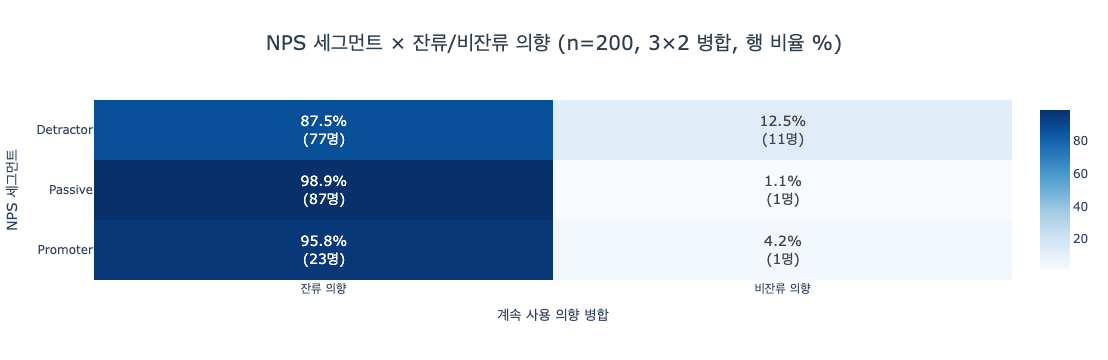

In [30]:
merged_pct = (merged_pivot.div(merged_pivot.sum(axis=1), axis=0) * 100).round(1)
merged_text = [
    [f"{merged_pct.iloc[i, j]:.1f}%<br>({int(merged_pivot.iloc[i, j])}명)" for j in range(merged_pct.shape[1])]
    for i in range(merged_pct.shape[0])
]

fig = go.Figure(go.Heatmap(
    z=merged_pct.values,
    x=['잔류 의향', '비잔류 의향'],
    y=SEGMENT_ORDER,
    colorscale='Blues',
    text=merged_text,
    texttemplate='%{text}',
    textfont=dict(size=14),
    showscale=True
))
fig.update_layout(
    title=dict(text=f'NPS 세그먼트 × 잔류/비잔류 의향 (n={int(merged_pivot.values.sum())}, 3×2 병합, 행 비율 %)', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='계속 사용 의향 병합',
    yaxis_title='NPS 세그먼트'
)
fig.show()

In [31]:
chi2_m, p_m, dof_m, expected_m = stats.chi2_contingency(merged_pivot)
n_m = merged_pivot.values.sum()
cramers_v_m = np.sqrt(chi2_m / (n_m * min(merged_pivot.shape[0] - 1, merged_pivot.shape[1] - 1)))
below5_m = (expected_m < 5).sum()

print(f'3x2 병합 재검정 — Chi2={chi2_m:.3f}, p={p_m:.4f}, df={dof_m}')
print(f"Cramér's V (병합) = {cramers_v_m:.3f} (df*=1 기준 small=0.10/medium=0.30)")
print(f'기대빈도 5 미만 셀: {below5_m}개 / 전체 {expected_m.size}개')
merged_pivot

3x2 병합 재검정 — Chi2=9.593, p=0.0083, df=2
Cramér's V (병합) = 0.219 (df*=1 기준 small=0.10/medium=0.30)
기대빈도 5 미만 셀: 1개 / 전체 6개


,잔류 의향,비잔류 의향
nps_segment,,
Promoter,23.0,1.0
Passive,87.0,1.0
Detractor,77.0,11.0


In [32]:
# 각 세그먼트 기댓값
expected_m_df = pd.DataFrame(
    expected_m,
    index=SEGMENT_ORDER,
    columns=['잔류 의향', '비잔류 의향']
).round(2)
expected_m_df

,잔류 의향,비잔류 의향
Promoter,22.44,1.56
Passive,82.28,5.72
Detractor,82.28,5.72


In [33]:
# 1. 병합된 데이터 기준 행/열 비율 및 기대빈도 설정
n_total_m = n_m  # 병합 후 총 샘플 수
row_prop_m = merged_pivot.sum(axis=1).values / n_total_m
col_prop_m = merged_pivot.sum(axis=0).values / n_total_m

# 2. 조정된 표준화 잔차 계산 공식 적용
# np.outer를 통해 (행 비율 보정값 x 열 비율 보정값)의 매트릭스를 생성합니다.
adj_residuals_m = (merged_pivot.values - expected_m) / np.sqrt(
    expected_m * np.outer(1 - row_prop_m, 1 - col_prop_m)
)

# 3. 데이터프레임 변환 및 반올림
MERGED_CONTINUE_ORDER = ['잔류 의향', '비잔류 의향']
adj_residuals_m_df = pd.DataFrame(
    adj_residuals_m, 
    index=SEGMENT_ORDER, 
    columns=MERGED_CONTINUE_ORDER
).round(2)

# 결과 확인
adj_residuals_m_df

,잔류 의향,비잔류 의향
Promoter,0.49,-0.49
Passive,2.73,-2.73
Detractor,-3.05,3.05


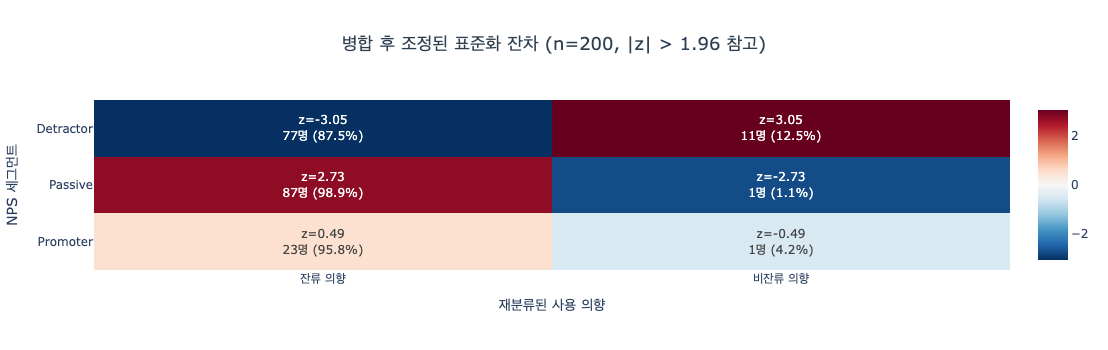

In [34]:
# 히트맵 객체 생성
merged_residual_text = [
    [
        f"z={adj_residuals_m_df.iloc[i, j]:.2f}<br>{int(merged_pivot.iloc[i, j])}명 ({merged_pct.iloc[i, j]:.1f}%)"
        for j in range(adj_residuals_m_df.shape[1])
    ]
    for i in range(adj_residuals_m_df.shape[0])
]

fig = go.Figure(go.Heatmap(
    z=adj_residuals_m_df.values,
    x=MERGED_CONTINUE_ORDER,
    y=SEGMENT_ORDER,
    colorscale='RdBu_r',
    zmid=0,                       # 0을 기준으로 Blue(양수)와 Red(음수) 정렬
    text=merged_residual_text,
    texttemplate='%{text}',
    showscale=True
))

# 레이아웃 업데이트
fig.update_layout(
    title=dict(
        text=f'병합 후 조정된 표준화 잔차 (n={int(merged_pivot.values.sum())}, |z| > 1.96 참고)', 
        x=0.5, 
        xanchor='center', 
        font=dict(size=18, color='#2c3e50')
    ),
    xaxis_title='재분류된 사용 의향',
    yaxis_title='NPS 세그먼트',
    plot_bgcolor='white',
    height=350
)

# 시각화 출력
fig.show()

### 가설 2 판정: 지지(효과 크기 제한)
_분할표 SQL: `segment_continue_cross` (GROUP BY) · 검정: scipy 카이제곱 + 조정 표준화잔차_


| 검정 | 변수 | Chi2 | df(검정 자유도) | df*(V 해석) | p-value | Cramér's V | 해석 |
|------|------|------|----------------|-------------|---------|-----------|------|
| 원본 3×5 교차표 | NPS × 계속 사용 의향 | 34.008 | 8 | 2 | <0.001 | 0.292 | 기대빈도 조건 위반으로 참고용 |
| **병합 3×2 교차표** | NPS × 잔류/비잔류 | **9.593** | **2** | **1** | **0.008** | **0.219** | **약함-중간 수준의 관계** |

> `df`·`df*`·기대빈도 가정 → [docs/METHODS.md](../docs/METHODS.md#카이제곱-pearsons-chi-squared). 병합 후에도 기대빈도 5 미만 셀 1개가 남아 결과는 방향성 확인용이다.

> ### 섹션 결론
> - 병합 3×2 기준으로 NPS 세그먼트와 잔류/비잔류 의향은 독립이라고 보기 어렵다(Chi2=**9.593**, p=**0.008**).
> - 효과 크기는 Cramér's V=**0.219** 로 크지 않아, NPS만으로 잔류를 강하게 예측하기는 어렵다.
> - 따라서 Detractor 🔴는 즉시 이탈층보다 **추천 의향과 적극적 잔류 강도가 낮은 소극적 잔류층** 으로 해석한다.


---

## 3. 비추천층의 불만족 경험
- Q13. 패션 플랫폼에서 구매한 경험이 있다면, 불만족스러웠던 경험이 있나요? (복수 선택)

Detractor를 중심으로 불만족 경험 패턴을 비교해, 낮은 추천 의향이 특정 불만 항목에 집중되는지 확인한다.

---

**분석 질문 3** — 플랫폼을 추천하지 않는 사용자(Detractor)는 사이즈 문제와 사진-실물 불일치를 다른 사용자보다 더 많이 경험했는가?

- 근거: EDA에서 전 플랫폼 공통 불만족 1·2위가 사이즈·사진 불일치
- 분석 방법: 전체 vs Detractor 불만족 경험 비율 비교(기술통계)
- 해석 기준: Q13은 복수 선택 문항이므로 검정보다는 응답자 기준 비율 차이를 중심으로 본다.

In [35]:
EXCLUDE_DIS = {'불만족 경험 없음', '구매 경험 자체가 없음'}

def explode_dis_count(sub):
    return (
        sub['dissatisfaction'].dropna()
        .str.split(', ')
        .explode()
        .str.strip()
        .pipe(lambda s: s[~s.isin(EXCLUDE_DIS)])
        .value_counts()
        .reset_index()
        .rename(columns={'dissatisfaction': '불만족 경험', 'count': '응답자 수'})
    )

# 분모: 세그먼트별 전체 응답자 수 (다중응답 표준 — 합이 100% 넘을 수 있음)
n_all = len(df)
n_det = len(df[df['nps_segment'] == 'Detractor'])

dis_all = explode_dis_count(df).rename(columns={'응답자 수': '전체'})
dis_det = explode_dis_count(df[df['nps_segment'] == 'Detractor']).rename(columns={'응답자 수': 'Detractor'})

dis_compare = (
    dis_all
    .merge(dis_det, on='불만족 경험', how='outer')
    .fillna(0)
    .assign(
        전체_분모=n_all,
        Detractor_분모=n_det,
        전체_pct=lambda x: (x['전체'] / x['전체_분모'] * 100).round(1),
        Detractor_pct=lambda x: (x['Detractor'] / x['Detractor_분모'] * 100).round(1),
        차이_pp=lambda x: (x['Detractor_pct'] - x['전체_pct']).round(1)
    )
    .sort_values('전체_pct', ascending=False)
)
dis_compare

,불만족 경험,전체,Detractor,전체_분모,Detractor_분모,전체_pct,Detractor_pct,차이_pp
2,사이즈 문제,102,41,200,88,51.0,46.6,-4.4
3,실제 상품이 사진과 달랐음,88,39,200,88,44.0,44.3,0.3
1,배송이 느렸음,48,20,200,88,24.0,22.7,-1.3
0,반품 / 교환 과정이 불편했음,45,23,200,88,22.5,26.1,3.6


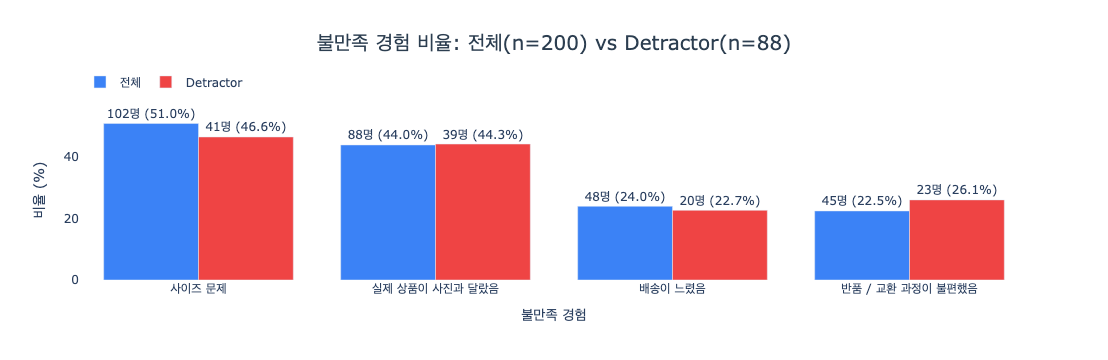

In [36]:
fig = go.Figure()
fig.add_trace(go.Bar(
    name='전체',
    x=dis_compare['불만족 경험'],
    y=dis_compare['전체_pct'],
    marker_color='#3B82F6',
    text=[f"{int(n)}명 ({pct:.1f}%)" for n, pct in zip(dis_compare['전체'], dis_compare['전체_pct'])],
    textposition='outside'
))
fig.add_trace(go.Bar(
    name='Detractor',
    x=dis_compare['불만족 경험'],
    y=dis_compare['Detractor_pct'],
    marker_color='#EF4444',
    text=[f"{int(n)}명 ({pct:.1f}%)" for n, pct in zip(dis_compare['Detractor'], dis_compare['Detractor_pct'])],
    textposition='outside'
))
fig.update_layout(
    barmode='group',
    title=dict(text=f'불만족 경험 비율: 전체(n={n_all}) vs Detractor(n={n_det})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='불만족 경험',
    yaxis_title='비율 (%)',
    yaxis=dict(range=[0, max(dis_compare['전체_pct'].max(), dis_compare['Detractor_pct'].max()) * 1.15]),
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

### 분석 질문 3 결과: Detractor 고유 집중 신호 없음
_집계: pandas (Q13 불만족 다중응답)_


**불만족 경험 응답자 비율 (전체 vs Detractor)** _(분모: 각 그룹 전체 응답자 수, 다중응답이라 합은 100% 초과 / 표의 항목명은 원문 응답값을 읽기 쉽게 축약)_

| 불만족 경험 | 전체 (n=200) | Detractor (n=88) | 차이 (D-전체) | 해석 |
|-----------|------------|----------------|-------------|------|
| 사이즈 문제 | 102명 (51.0%) | 41명 (46.6%) | **-4.4%p** | Detractor가 오히려 낮음 |
| 사진-실물 불일치 | 88명 (44.0%) | 39명 (44.3%) | +0.3%p | 거의 동일 |
| 배송 지연 | 48명 (24.0%) | 20명 (22.7%) | -1.3%p | 거의 동일 |
| 반품/교환 불편 | 45명 (22.5%) | 23명 (26.1%) | +3.6%p | Detractor가 약간 높음 |

**통계 검정 미수행 사유**
Q13은 복수 선택 문항이므로 응답 항목 간 독립성이 약하다. 따라서 검정보다는 응답자 기준 비율 비교로 해석한다.

> ### 섹션 결론
> - Detractor 🔴의 불만족 경험은 전체 응답자 분포와 전반적으로 유사하다.
> - 사이즈 문제와 사진-실물 불일치는 Detractor에서 더 높게 나타나지 않고, 반품/교환 불편만 **+3.6%p** 높다.
> - 따라서 Detractor만의 고유한 불만 집중 신호는 약하며, 사이즈/사진 정보 개선은 특정 세그먼트 전용 과제보다 **전체 사용자 경험 개선 과제** 로 보는 편이 적절하다.

---

## 4. NPS와 사용자 특성
- Q1. 성별을 선택해주세요.
- Q2. 연령대를 선택해주세요.
- Q3. 평소 패션/스타일 관련 콘텐츠를 얼마나 자주 찾아보시나요?
- Q4. 한 달 평균 패션 관련 지출은 얼마인가요? (의류, 신발, 액세서리 포함)
---
이 섹션은 NPS를 설명하는 확정 요인을 찾기보다, 추천 의향이 어떤 사용자 특성과 함께 움직이는지 탐색한다.

앞선 섹션들이 NPS 세그먼트별 태도·재구매 이유·불만족 경험을 확인했다면, 이 섹션은 그 차이가 특정 인구통계나 패션 관여도에서도 함께 관찰되는지 보조적으로 살펴본다. 다만 표본 크기와 횡단면 설문 한계상 원인이나 타겟 전략으로 단정하지 않고, 후속 분석에서 확인할 질문 수준으로 해석한다.

먼저 성별·연령은 NPS 세그먼트별 프로파일을 기술통계로 확인하고, 이어서 콘텐츠 탐색 빈도와 월 지출은 NPS 원점수와의 순위 상관으로 가볍게 확인한다.


---
## 4-1. 인구통계 프로파일링

**분석 질문 4-1** — 성별과 연령대는 NPS 세그먼트별로 어떻게 분포하는가?

- 분석 방법: NPS 세그먼트 × 성별/연령대 기술통계 분포 비교
- 해석 기준: 원인 규명이나 타겟 전략 확정이 아니라, 추천 의향이 높은/낮은 사용자군의 표본 특성을 파악하기 위한 기술통계로 해석한다.

In [37]:
# 세그먼트 × 성별 카운트는 SQL에서 (gender_by_segment — GROUP BY)
gender_seg = (
    run('gender_by_segment')
    .pivot(index='nps_segment', columns='gender', values='n')
    .reindex(SEGMENT_ORDER).fillna(0).astype(int)
)
gender_seg_pct = (gender_seg.div(gender_seg.sum(axis=1), axis=0) * 100).round(1)
gender_total_n = int(gender_seg.values.sum())
female_total_n = int(gender_seg['여성'].sum())
male_total_n = int(gender_seg['남성'].sum())
gender_seg_pct

gender,남성,여성
nps_segment,,
Promoter,25.0,75.0
Passive,36.4,63.6
Detractor,46.6,53.4


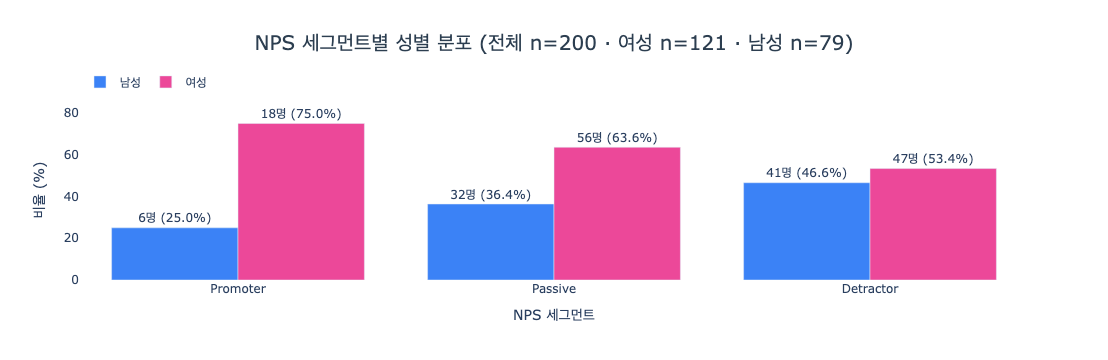

In [38]:
fig = go.Figure()
for gender, color in [('남성', '#3B82F6'), ('여성', '#EC4899')]:
    label_text = [
        f"{int(gender_seg.loc[segment, gender])}명 ({gender_seg_pct.loc[segment, gender]:.1f}%)"
        for segment in SEGMENT_ORDER
    ]
    fig.add_trace(go.Bar(
        name=gender,
        x=SEGMENT_ORDER,
        y=gender_seg_pct[gender],
        marker_color=color,
        text=label_text,
        textposition='outside'
    ))

fig.update_layout(
    barmode='group',
    title=dict(text=f'NPS 세그먼트별 성별 분포 (전체 n={gender_total_n} · 여성 n={female_total_n} · 남성 n={male_total_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='NPS 세그먼트',
    yaxis_title='비율 (%)',
    yaxis=dict(range=[0, gender_seg_pct.values.max() * 1.15]),
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

In [39]:
AGE_ORDER = ['10대', '20대 초중반', '20대 후반', '30대', '40대 이상']

# 세그먼트 × 연령 카운트도 SQL에서 (age_by_segment — GROUP BY)
age_seg = (
    run('age_by_segment')
    .pivot(index='nps_segment', columns='age', values='n')
    .reindex(index=SEGMENT_ORDER, columns=AGE_ORDER, fill_value=0).fillna(0).astype(int)
)
age_seg_pct = (age_seg.div(age_seg.sum(axis=1), axis=0) * 100).round(1)
age_seg_pct

age,10대,20대 초중반,20대 후반,30대,40대 이상
nps_segment,,,,,
Promoter,4.2,54.2,41.7,0.0,0.0
Passive,3.4,38.6,34.1,19.3,4.5
Detractor,3.4,36.4,33.0,19.3,8.0


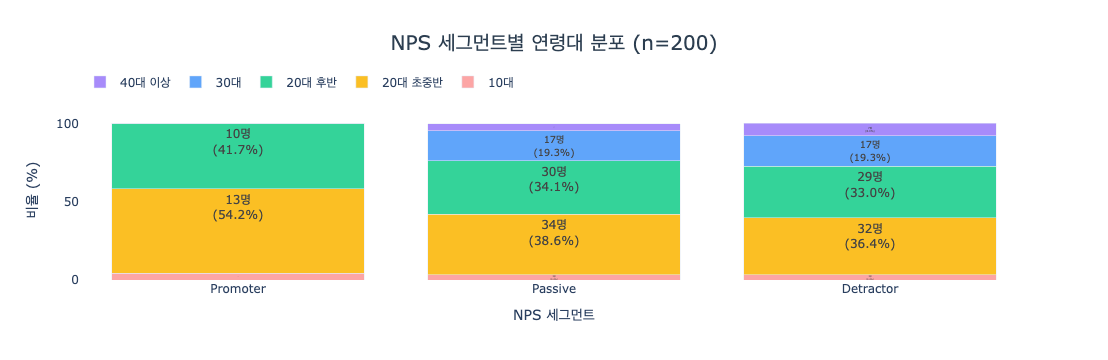

In [40]:
AGE_COLORS = ['#FCA5A5', '#FBBF24', '#34D399', '#60A5FA', '#A78BFA']

fig = go.Figure()
for age, color in zip(AGE_ORDER, AGE_COLORS):
    label_text = [
        f"{int(age_seg.loc[segment, age])}명<br>({age_seg_pct.loc[segment, age]:.1f}%)"
        for segment in SEGMENT_ORDER
    ]
    fig.add_trace(go.Bar(
        name=age,
        x=SEGMENT_ORDER,
        y=age_seg_pct[age],
        marker_color=color,
        text=label_text,
        textposition='inside'
    ))

fig.update_layout(
    barmode='stack',
    title=dict(text=f'NPS 세그먼트별 연령대 분포 (n={age_seg.values.sum()})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='NPS 세그먼트',
    yaxis_title='비율 (%)',
    yaxis=dict(range=[0, 115]),
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

nps_segment,Promoter,Passive,Detractor
demo_group,,,
남성 · 10대,0명 (0.0%),2명 (40.0%),3명 (60.0%)
남성 · 20대,6명 (10.3%),21명 (36.2%),31명 (53.4%)
남성 · 30대 이상,0명 (0.0%),9명 (56.2%),7명 (43.8%)
여성 · 10대,1명 (50.0%),1명 (50.0%),0명 (0.0%)
여성 · 20대,17명 (18.9%),43명 (47.8%),30명 (33.3%)
여성 · 30대 이상,0명 (0.0%),12명 (41.4%),17명 (58.6%)


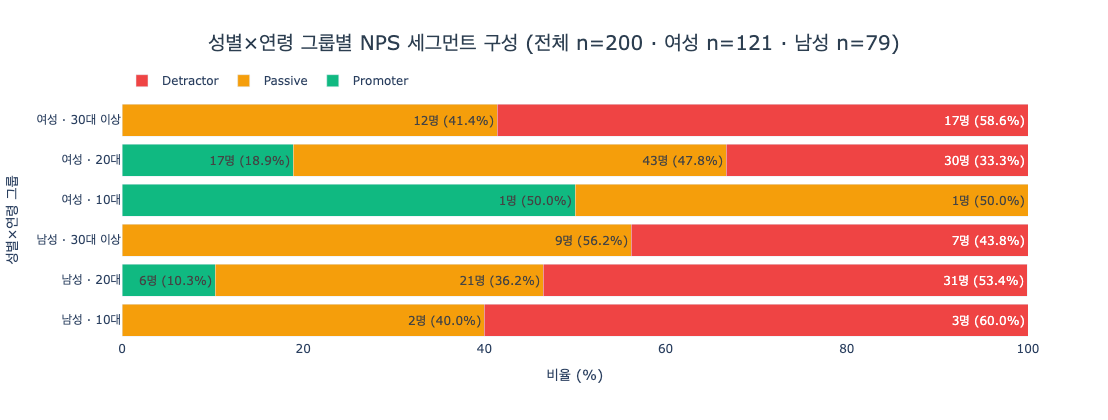

In [41]:
AGE_BUCKET_ORDER = ['10대', '20대', '30대 이상']
DEMO_GROUP_ORDER = [
    f'{gender} · {age_bucket}'
    for gender in ['남성', '여성']
    for age_bucket in AGE_BUCKET_ORDER
]

demo_df = df.assign(
    age_bucket=lambda x: np.select(
        [
            x['age'].eq('10대'),
            x['age'].isin(['20대 초중반', '20대 후반']),
            x['age'].isin(['30대', '40대 이상']),
        ],
        AGE_BUCKET_ORDER,
        default='기타'
    )
).assign(
    demo_group=lambda x: x['gender'] + ' · ' + x['age_bucket']
)

demo_counts = (
    demo_df.groupby(['demo_group', 'nps_segment'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=DEMO_GROUP_ORDER, columns=SEGMENT_ORDER, fill_value=0)
)
demo_counts = demo_counts[demo_counts.sum(axis=1) > 0]
demo_total_n = int(demo_counts.values.sum())
demo_female_n = int((demo_df['gender'] == '여성').sum())
demo_male_n = int((demo_df['gender'] == '남성').sum())
demo_pct = (demo_counts.div(demo_counts.sum(axis=1), axis=0) * 100).round(1)

demo_segment_summary = demo_counts.astype(str) + '명 (' + demo_pct.astype(str) + '%)'
display(demo_segment_summary)

fig = go.Figure()
for segment in SEGMENT_ORDER:
    label_text = [
        f'{int(demo_counts.loc[group, segment])}명 ({demo_pct.loc[group, segment]:.1f}%)'
        for group in demo_counts.index
    ]
    fig.add_trace(go.Bar(
        name=segment,
        x=demo_pct[segment],
        y=demo_counts.index,
        orientation='h',
        marker_color=SEGMENT_COLORS[segment],
        text=label_text,
        textposition='inside'
    ))

fig.update_layout(
    barmode='stack',
    title=dict(text=f'성별×연령 그룹별 NPS 세그먼트 구성 (전체 n={demo_total_n} · 여성 n={demo_female_n} · 남성 n={demo_male_n})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    xaxis_title='비율 (%)',
    yaxis_title='성별×연령 그룹',
    xaxis=dict(range=[0, 100]),
    plot_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    height=420
)
fig.show()

### 분석 질문 4-1 결과: Promoter는 20대 여성 비중이 높음
_사용 SQL: `gender_by_segment` · `age_by_segment` — GROUP BY_


아래 표는 **각 NPS 세그먼트 내부 구성비** 를 기준으로 읽는다. 즉 Promoter 🟢는 24명, Passive 🟡는 88명, Detractor 🔴는 88명을 각각 분모로 계산했다.

| 변수 | Promoter 🟢 (n=24) | Passive 🟡 (n=88) | Detractor 🔴 (n=88) | 패턴 |
|------|------------|------------|--------------|------|
| 여성 비율 | **18명 (75.0%)** | 56명 (63.6%) | 47명 (53.4%) | Promoter 🟢에서 여성 비중이 높음 |
| 20대 비율 | **23명 (95.8%)** | 64명 (72.7%) | 61명 (69.3%) | 표본 내 Promoter 🟢에서 20대 비중이 높음 |
| 30대 이상 비율 | 0명 (0.0%) | 21명 (23.9%) | 24명 (27.3%) | Detractor 🔴에서 상대적으로 높음 |

**보조 관찰 — 성별×연령 조합 기준**
- 이 보조 관찰은 위 표와 반대로 **각 성별×연령 조합 내부 구성비** 를 기준으로 읽는다.
- 여성·20대 그룹(n=90)에서는 Promoter 🟢가 **17명(18.9%)** 으로 조합별 Promoter 수가 가장 많다.
- 남성·20대 그룹(n=58)은 Detractor 🔴가 **31명(53.4%)**, 여성·30대 이상 그룹(n=29)은 Detractor 🔴가 **17명(58.6%)** 으로 상대적으로 높다.
- 다만 조합별 표본 크기가 작으므로, 이 결과는 타겟 확정보다 후속 관찰 포인트로 해석한다.

> ### 섹션 결론
> - Promoter 🟢(n=24)는 표본 내에서 **여성 18명(75.0%)**, **20대 23명(95.8%)** 로 특정 특성이 두드러진다.
> - 성별×연령을 함께 보면 여성·20대(n=90)에서는 Promoter 🟢가 17명(18.9%)으로 가장 많이 나타나고, 남성·20대(n=58)와 여성·30대 이상(n=29)에서는 Detractor 🔴 비율이 상대적으로 높다.
> - 다만 조합별 표본 크기가 작아, 원인이나 확정적 타겟 전략으로 단정하지 않는다.
> - 이 파트는 원인 분석이 아니라 NPS 세그먼트의 사용자 프로필을 확인하는 보조 분석으로 활용한다.

---

## 4-2. NPS 원점수와 적극성·지출의 관계

**분석 질문 4-2** — 패션 콘텐츠를 더 자주 탐색하거나 월 지출이 많은 사용자일수록 NPS 추천 점수가 높게 나타나는가?

- 근거: `02_eda`에서 content_freq × monthly_spend 스피어만 ρ=0.543으로 두 변수가 함께 움직이는 경향이 관찰됨
- 분석 방법: NPS 원점수(0-10) × content_freq / monthly_spend 스피어만 순위 상관
- 해석 기준: p-value보다 상관 방향과 효과 크기를 중심으로 본다.

**NPS는 세그먼트가 아닌 원점수(0-10) 사용** — 세그먼트로 묶으면 정보 손실이 발생하므로, 순서형 변수 간 관계는 원점수 기준으로 확인한다.


In [42]:
# content_score는 SQL 뷰(nps_scored)에서 매핑됨 → 스피어만만 (검정은 SQL 부적합)
content_df = df[['nps', 'content_freq', 'content_score']].dropna(subset=['nps', 'content_score']).copy()
rho_c, p_c = stats.spearmanr(content_df['nps'], content_df['content_score'])
print(f'NPS × 콘텐츠 탐색 빈도 — Spearman ρ={rho_c:.3f}, p={p_c:.4f}, n={len(content_df)}')

NPS × 콘텐츠 탐색 빈도 — Spearman ρ=0.298, p=0.0000, n=200


In [43]:
# spend_score도 SQL 뷰에서 매핑됨 → 스피어만만
spend_df = df[['nps', 'monthly_spend', 'spend_score']].dropna(subset=['nps', 'spend_score']).copy()
rho_s, p_s = stats.spearmanr(spend_df['nps'], spend_df['spend_score'])
print(f'NPS × 월 지출 — Spearman ρ={rho_s:.3f}, p={p_s:.4f}, n={len(spend_df)}')

NPS × 월 지출 — Spearman ρ=0.216, p=0.0021, n=200


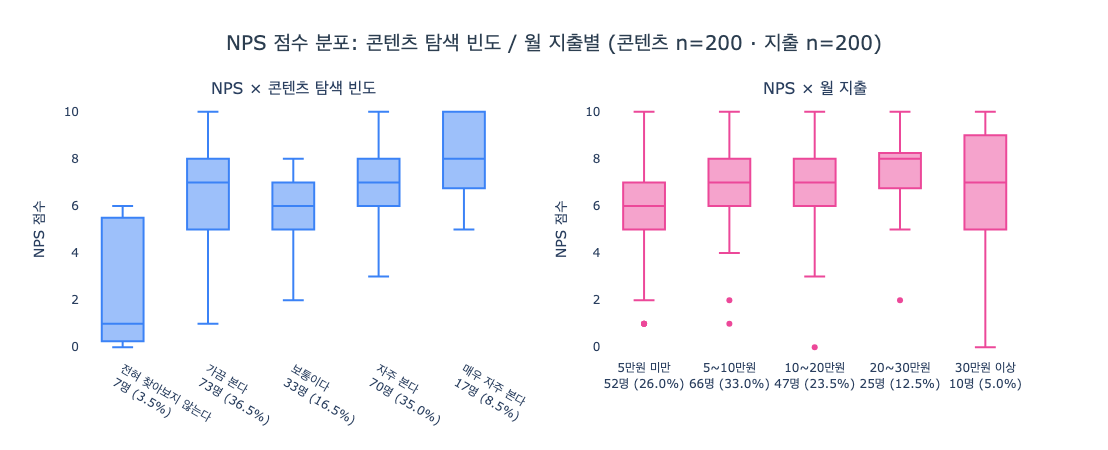

In [44]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2, subplot_titles=('NPS × 콘텐츠 탐색 빈도', 'NPS × 월 지출'))

CONTENT_ORDER = ['전혀 찾아보지 않는다', '가끔 본다', '보통이다', '자주 본다', '매우 자주 본다']
for cat in CONTENT_ORDER:
    vals = content_df[content_df['content_freq'] == cat]['nps']
    label = f"{cat}<br>{len(vals)}명 ({len(vals) / len(content_df) * 100:.1f}%)"
    fig.add_trace(go.Box(y=vals, name=label, marker_color='#3B82F6', showlegend=False), row=1, col=1)

SPEND_ORDER = ['5만원 미만', '5~10만원', '10~20만원', '20~30만원', '30만원 이상']
for cat in SPEND_ORDER:
    vals = spend_df[spend_df['monthly_spend'] == cat]['nps']
    label = f"{cat}<br>{len(vals)}명 ({len(vals) / len(spend_df) * 100:.1f}%)"
    fig.add_trace(go.Box(y=vals, name=label, marker_color='#EC4899', showlegend=False), row=1, col=2)

fig.update_layout(
    title=dict(text=f'NPS 점수 분포: 콘텐츠 탐색 빈도 / 월 지출별 (콘텐츠 n={len(content_df)} · 지출 n={len(spend_df)})', x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    height=450
)
fig.update_yaxes(title_text='NPS 점수', range=[-0.5, 10.5])
fig.show()

### 분석 질문 4-2 결과: 약한 양의 관계
_점수: SQL 뷰 `nps_scored` (content_score·spend_score) · 검정: scipy 스피어만_


| 변수 | Spearman ρ | p-value | 강도 | 해석 |
|------|-----------|---------|------|------|
| NPS × 콘텐츠 탐색 빈도 | **0.298** | <0.001 | Weak | 탐색 빈도가 높을수록 NPS가 높아지는 약한 경향 |
| NPS × 월 지출 | **0.216** | 0.002 | Weak | 월 지출이 높을수록 NPS가 높아지는 약한 경향 |

> ### 섹션 결론
> - 콘텐츠 탐색 빈도(ρ=**0.298**)와 월 지출(ρ=**0.216**)은 모두 NPS와 약한 양의 관계를 보인다.
> - 두 변수 중에서는 콘텐츠 탐색 빈도가 NPS와 조금 더 가깝게 움직인다.
> - 다만 효과 크기가 작으므로, 추천 의향은 상품 만족·플랫폼 경험·브랜드 선호와 함께 해석해야 한다.


---

## 결론 및 핵심 인사이트

NPS는 낮지만 즉각적인 이탈 의향은 제한적이다. 설문 응답자 기준 Detractor는 곧바로 떠나는 집단이라기보다, 추천 의향과 적극적 잔류 강도가 낮은 **소극적 잔류층** 에 가깝다. 재구매 이유에서는 관성, 불만족 경험에서는 특정 항목 집중 없음, 사용자 특성에서는 패션 탐색 적극성도 함께 나타나, NPS는 단일 불만보다 전반적 관여도와 사용 경험의 복합 신호로 해석하는 것이 적절하다.

---

### 통계/기술 분석 요약

| 섹션 | 분석 방법 | 결과 |
|------|---------|------|
| NPS 분류·요약 | NPS 표준 세그먼트 분류 | NPS Score -32.0, Promoter 🟢 24명 (12.0%), Passive 🟡 88명 (44.0%), Detractor 🔴 88명 (44.0%) |
| 플랫폼 선택자별 NPS | Q6 선택 플랫폼별 NPS·세그먼트 구성 참고 비교 | 공식 플랫폼 평가가 아니라 선택자군의 추천 의향 분포로 해석 |
| 분석 질문 1 — 세그먼트별 재구매 이유 차이 | 다중응답 비율 비교 | Promoter는 브랜드/상품 응답이 높고, Passive/Detractor는 관성 응답이 상대적으로 높음 |
| 가설 2 — NPS × 계속 사용 의향 | 카이제곱 독립성 검정 + 잔류/비잔류 병합 재검정 | 지지(효과 크기 제한): 병합 기준 Chi2=9.593, p=0.008, Cramér's V=0.219 |
| 분석 질문 3 — Detractor 불만족 집중 | 다중응답 비율 비교 | Detractor만의 특정 불만 집중 신호는 약함 |
| 분석 질문 4-1 — 인구통계 프로파일링 | 세그먼트별 기술통계 | Promoter는 표본 내 20대 여성 비중이 높음 |
| 분석 질문 4-2 — NPS × 적극성·지출 | 스피어만 순위 상관 | 약한 양의 관계: 콘텐츠 탐색 ρ=0.298, 월 지출 ρ=0.216 |

---

### 핵심 발견 요약

- **발견 1: NPS는 낮지만 사용 의향은 높다.** NPS Score는 -32.0이지만, 잔류 의향은 187명(93.5%)이다.
- **발견 2: Passive 🟡와 Detractor 🔴가 핵심 관찰 대상이다.** 두 세그먼트가 각각 88명(44.0%)으로 가장 큰 비중을 차지한다.
- **발견 3: 재구매 이유의 차이는 혜택보다 관성에서 더 선명하다.** `익숙해서` 응답은 Promoter 🟢 4명(16.7%), Passive 🟡 28명(32.9%), Detractor 🔴 27명(32.9%)이다.
- **발견 4: Detractor는 즉시 이탈층이라기보다 소극적 잔류층에 가깝다.** 전체 명확한 이탈 의향자는 4명이며, 이 중 Detractor가 3명(Detractor 내 3.4%)이다.
- **발견 5: Detractor만의 특정 불만 트리거는 약하다.** Detractor의 불만족 경험 분포는 전체와 크게 다르지 않다.
- **발견 6: 추천 의향은 구매 규모보다 패션 탐색 적극성과 더 가깝게 움직인다.** 콘텐츠 탐색 빈도와의 상관이 월 지출보다 높다.

---

> 발견별 상세 근거·해석은 각 섹션의 `섹션 결론`을, 통계 방법론은 [docs/METHODS.md](../docs/METHODS.md)를 참조한다.


---

### SQL 기법 매핑

이 노트북에서 각 분석을 산출한 SQL 쿼리와 기법(검정·다중응답·NLP는 pandas).

| 섹션 | SQL 쿼리 | 기법 |
|------|---------|------|
| 1 재구매 이유 (Q12) | — | 다중응답 → pandas |
| 2 의향 × NPS 세그먼트 | `segment_continue_cross` | GROUP BY (검정 scipy 카이제곱·잔차) |
| 3 Detractor 불만족 (Q13) | — | 다중응답 → pandas |
| 4-1 세그먼트 인구통계 | `gender_by_segment`·`age_by_segment` | GROUP BY |
| 4-2 NPS × 콘텐츠/지출 | 뷰 `nps_scored` | CASE WHEN 점수화 (검정 scipy) |
